<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme de Newton </h1>
</center>

## Implémentation 
 
1. Coder l’algorithme de Newton dans le fichier `src/newton.jl` en respectant la spécification donnée dans ce même fichier ;
2. Exécuter les tests ci-dessous et vérifier qu'ils passent.

Pour les tests, nous avons défini les fonctions suivantes $f_1 \colon \mathbb{R}^3 \to \mathbb{R}$
et $f_2 \colon \mathbb{R}^2 \to \mathbb{R}$.

$$
    f_{1}(x_1, x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$
et
$$
    f_{2}(x_1,x_2) = 100(x_2-x_1^2)^2 + (1-x_1)^2.
$$

**Remarque.** On peut retrouver ces fonctions dans le fichier `test/fonctions_de_tests.jl`.

In [1]:
include("../src/newton.jl")         # votre algorithme de Newton
include("../test/tester_newton.jl") # la fonction pour tester votre algorithme de Newton

#
afficher = false # si true, alors affiche les résultats des algorithmes

#
tester_newton(newton, afficher); # tester l'algorithme de Newton

Affichage des résultats des algorithmes : false

Test Summary:        | Pass  Total  Time
algorithme de Newton |   19     19  3.9s


In [2]:
include("../src/newton.jl") # votre algorithme de Newton
include("../test/fonctions_de_tests.jl") # pour avoir la fonction d'affichage des résultats

# Fonction f0
# -----------
f0(x)      =  sin(x)
grad_f0(x) =  cos(x) # la gradient de la fonction f0
hess_f0(x) = -sin(x) # la hessienne de la fonction f0
solution   = -pi/2

x0 = solution
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = -pi/2+0.5
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = pi/2
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)


-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = -1.5707963267948966
  * x_sol    = -1.5707963267948966
  * f(x_sol) = -1.0
  * nb_iters = 0
  * flag     = 0
  * solution = -1.5707963267948966
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = -1.0707963267948966
  * x_sol    = -1.5707963267949088
  * f(x_sol) = -1.0
  * nb_iters = 3
  * flag     = 0
  * solution = -1.5707963267948966
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = 1.5707963267948966
  * x_sol    = 1.5707963267948966
  * f(x_sol) = 1.0
  * nb_iters = 0
  * flag     = 0
  * solution = -1.5707963267948966


## Interprétation 

1. Justifier les résultats obtenus pour l'exemple $f_0$ ci-dessus.
2. Justifier que l’algorithme implémenté converge en une itération pour $f_{1}$.
3. Justifier que l’algorithme puisse ne pas converger pour $f_{2}$ avec certains points initiaux.
4. Proposez une stratégie permettant d’assurer la convergence de la méthode de Newton indépendamment du point initial. Décrivez l’idée sous-jacente et expliquez en quoi elle modifie ou sécurise l’itération de Newton standard.
5. Tracez l’évolution de la norme du gradient en fonction du numéro d’itération pour $f_2$. Identifiez et expliquez l’itération à partir de laquelle la méthode entre dans le régime de convergence quadratique. 
6. Discutez de l’importance du fait que la matrice hessienne soit inversible à chaque itération. Avez-vous rencontré des exemples où cette condition n’était pas satisfaite ? Si oui, décrivez le comportement observé et son impact sur la convergence.
7. Expliquez pourquoi il est essentiel que la matrice hessienne soit localement définie positive au point optimal lors de l’application de la méthode de Newton pour la minimisation. Reliez cette propriété à la nature du point stationnaire et à la direction de descente.


**Remarque.** Vous pouvez mettre `affiche=true` dans les tests de l'algorithme de Newton pour
vous aider.


## Réponses

1. f0 = sin(x)  
    x0=−π/2 (solution) : Arrêt immédiat (0 itération) car le gradient est déjà nul.  
    x0≈−π/2 : Converge vers le minimum car la fonction est localement convexe (∇2f>0).  
    x0=π/2 : Converge vers un maximum. Newton cherche les points critiques (∇f=0) sans distinguer minimum et maximum (dépend du signe de la Hessienne).
    

2. f1 est une fonction quadratique. La méthode de Newton utilise une approximation quadratique locale de la fonction. Pour une fonction qui est déjà quadratique, cette approximation est exacte. Le minimum du modèle coincide donc parfaitement avec le minimum global dès la première étape.

3. La méthode de Newton n'a qu'une convergence locale. Si le point de départ est trop éloigné de la solution, l'approximation quadratique est mauvaise. Cela peut générer des pas trop grands ou dans de mauvaises directions, entraînant une divergence ou des oscillations.

4. Stratégie de convergence globale : Il faut utiliser une technique de globalisation, comme les Régions de Confiance  
    Idée : On définit une zone (boule de rayon Δk) autour de l'itéré où l'on fait confiance au modèle. On contraint le pas à rester dans cette zone. Si l'itération ne réduit pas suffisamment la fonction, on réduit la taille de la zone (Δk) au lieu de faire un grand saut risqué.

5. Convergence quadratique (Graphique) : Observez le graphique ci-dessous  
    Le régime de convergence quadratique correspond à la chute brutale de la courbe en fin de parcours.  
    Explication : C'est le moment où l'itéré est assez proche de la solution pour que l'approximation quadratique devienne excellente. Le nombre de décimales exactes double à chaque itération.

6. Importance de l'inversibilité de la Hessienne : L'algorithme doit résoudre le système linéaire ∇2f(xk)dk=−∇f(xk).  
    Impact : Si la matrice est singulière (non inversible), la direction dk n'est pas définie (division par zéro matricielle), ce qui provoque une erreur (SingularException) et l'arrêt de l'algorithme. C'est le cas pour certains points de f2.

7. Nature du point : Une Hessienne définie positive (∇2f(x∗)>0) garantit que le point critique est un minimum strict (courbure convexe), et non un maximum ou un point selle.

    Direction de descente : Si la Hessienne est définie positive, la direction de Newton dk=−(∇2f)−1∇f est garantie d'être une direction de descente (elle fait diminuer f). Sinon, on risque de remonter vers un sommet.


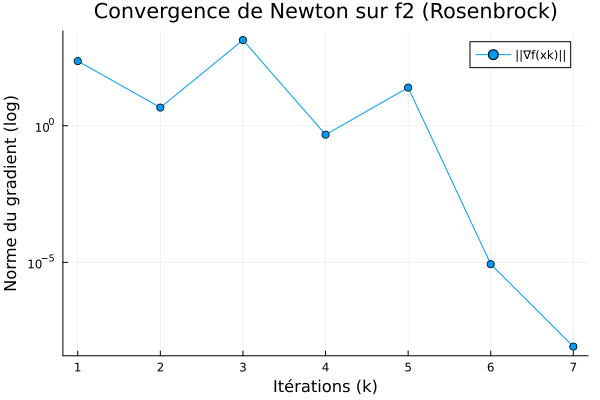

In [4]:
using Plots
using LinearAlgebra
include("../src/newton.jl")
include("../test/fonctions_de_tests.jl")

# Question 5 : Tracé de la convergence pour f2
x0 = [-1.2; 1.0]

# Exécution de Newton
x_sol, f_sol, flag, nb_iters, xs = newton(fct2, grad_fct2, hess_fct2, x0, max_iter=100)

# Calcul de la norme du gradient pour chaque itéré stocké dans xs
grad_norms = map(x -> norm(grad_fct2(x)), xs)

# Tracé
plot(grad_norms, 
    yaxis=:log, # Echelle logarithmique indispensable pour voir la convergence quadratique
    marker=:circle,
    label="||∇f(xk)||",
    title="Convergence de Newton sur f2 (Rosenbrock)",
    xlabel="Itérations (k)",
    ylabel="Norme du gradient (log)",
    legend=:topright
)